This notebook uses PCA to explore patterns in U.S. immigration between 1980-2022. PCA allows us to identify the immigration features that move together and the ones who operate separately.

In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [60]:
immigration = pd.read_csv('US Immigration Statistics (Ver 1.14.26).csv')
immigration = immigration[~immigration['Year'].isin([1991, 2003, 2020, 2021, 2022])]

immigration = immigration.rename(columns={
    "Immigrants Obtaining Lawful Permanent Resident Status": "Obtaintment of Permanent Residence"
})

print(immigration.head())

     Year Obtaintment of Permanent Residence Refugee Arrivals  \
0  1980.0                            524,295          207,116   
1  1981.0                            595,014          159,252   
2  1982.0                            533,624           98,096   
3  1983.0                            550,052           61,218   
4  1984.0                            541,811           70,393   

  Noncitizen Apprehensions Noncitizen Removals Noncitizen Returns  
0                  910,361              18,013            719,211  
1                  975,780              17,379            823,875  
2                  970,246              15,216            812,572  
3                1,251,357              19,211            931,600  
4                1,246,981              18,696            909,833  


In [61]:
immigration.columns

Index(['Year', 'Obtaintment of Permanent Residence', 'Refugee Arrivals',
       'Noncitizen Apprehensions', 'Noncitizen Removals',
       'Noncitizen Returns'],
      dtype='object')

In [62]:
#convert features to float type
immigration = immigration.dropna()

features = [
    "Obtaintment of Permanent Residence",
    "Refugee Arrivals",
    "Noncitizen Apprehensions",
    "Noncitizen Removals",
    "Noncitizen Returns"
]

for f in features:
    immigration[f] = (
        immigration[f].str.replace(",", "").astype(float)
    )

In [63]:
immigration.dtypes

Year                                  float64
Obtaintment of Permanent Residence    float64
Refugee Arrivals                      float64
Noncitizen Apprehensions              float64
Noncitizen Removals                   float64
Noncitizen Returns                    float64
dtype: object

In [64]:
#scale number of feature to be similar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(immigration.drop(columns=['Year']))

In [65]:
#view outliers
z_scores = np.abs(X_scaled)
outlier_years = immigration['Year'][np.any(z_scores > 2, axis=1)]
print(outlier_years.values)

[1980. 1981. 1990. 2000.]


In [66]:
#run PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

In [67]:
#df for PCA results
immigration_pca = pd.DataFrame(
    components,
    columns=['PC1', 'PC2']
)
immigration_pca['Year'] = immigration['Year'].values
print(immigration_pca.head())

        PC1       PC2    Year
0  1.697148  3.806488  1980.0
1  1.432154  2.571585  1981.0
2  1.067945  1.390802  1982.0
3  1.294599  0.102897  1983.0
4  1.348690  0.324697  1984.0


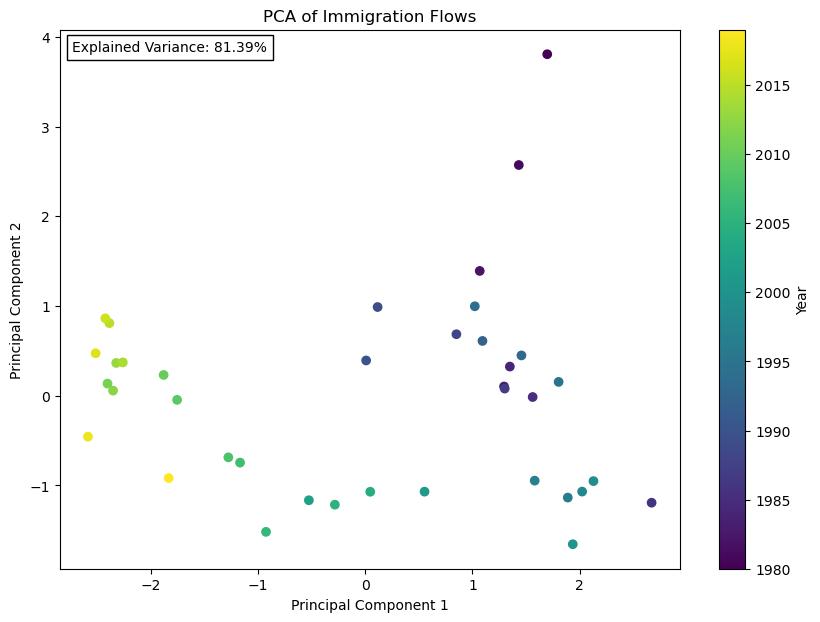

In [68]:
#plot PCA
explained = pca.explained_variance_ratio_.sum() * 100

plt.figure(figsize=(10, 7))

plt.scatter(
    immigration_pca["PC1"],
    immigration_pca["PC2"],
    c=immigration_pca["Year"]
)

plt.title("PCA of Immigration Flows")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.text(
    0.02, 0.98,
    f"Explained Variance: {explained:.2f}%",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white")
)

plt.colorbar(label="Year")

plt.show()

In [69]:
#df for PCA loadings 
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=immigration.drop(columns=["Year"]).columns
)

print(loadings)

                                         PC1       PC2
Obtaintment of Permanent Residence -0.415543 -0.246663
Refugee Arrivals                    0.257686  0.714104
Noncitizen Apprehensions            0.482387 -0.479873
Noncitizen Removals                -0.510126 -0.259940
Noncitizen Returns                  0.517683 -0.362444


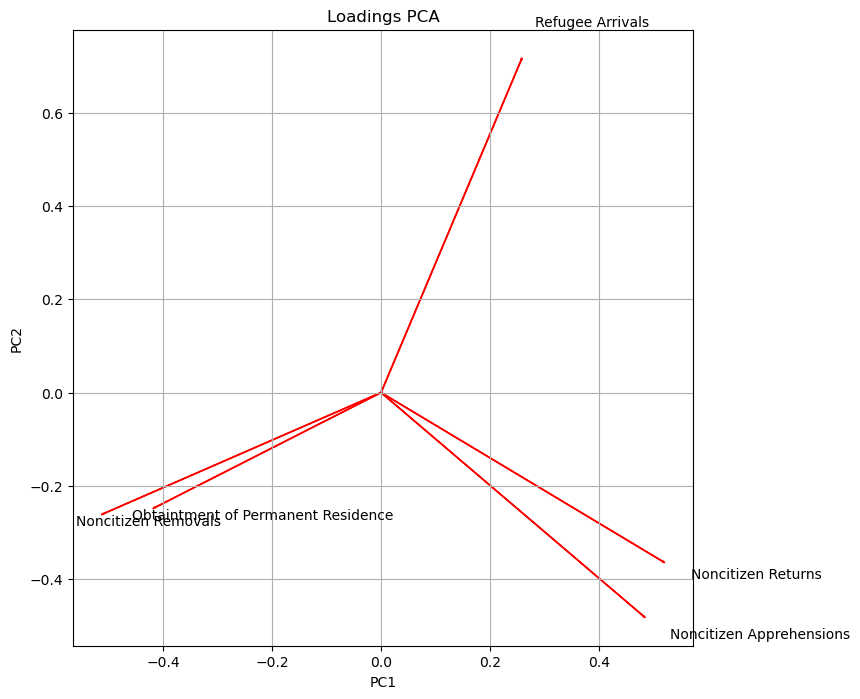

In [70]:
#plotted PCA loadings
plt.figure(figsize=(8, 8))

for feature in loadings.index:
    x = loadings.loc[feature, "PC1"]
    y = loadings.loc[feature, "PC2"]
    plt.arrow(0, 0, x, y, color="red")
    plt.text(x * 1.1, y * 1.1, feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Loadings PCA")
plt.grid(True)
plt.show()

The graph above indicates no relationship between refugee arrivals and noncitizen returns and noncitizen apprehensions. 

There also seems to be a positive correlation between noncitizen removals and obtainments of permanent residence statuses.

In [71]:
#calculate pc1 scores for each feature to see how much each one contributed
pc1_loadings = pd.Series(
    pca.components_[0],
    index=immigration.drop(columns=['Year']).columns
)

contributions = pd.DataFrame(
    X_scaled * pc1_loadings.values,
    columns=immigration.drop(columns=['Year']).columns
)
contributions['Year'] = immigration['Year'].values

print(contributions.head())

   Obtaintment of Permanent Residence  Refugee Arrivals  \
0                            0.650737          0.969106   
1                            0.530128          0.612278   
2                            0.634826          0.156358   
3                            0.606809         -0.118569   
4                            0.620864         -0.050169   

   Noncitizen Apprehensions  Noncitizen Removals  Noncitizen Returns    Year  
0                 -0.326957             0.572374           -0.168112  1980.0  
1                 -0.230662             0.574563           -0.054153  1981.0  
2                 -0.238808             0.582028           -0.066459  1982.0  
3                  0.174979             0.568240            0.063139  1983.0  
4                  0.168538             0.570017            0.039439  1984.0  


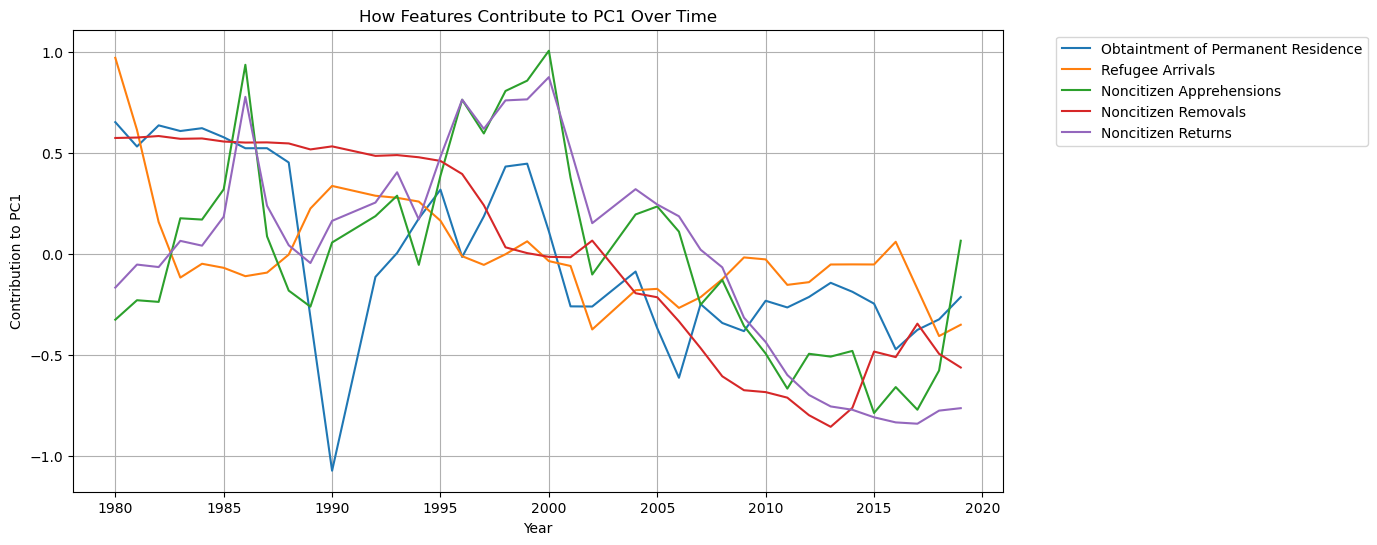

In [72]:
#plot pc1 contributions
fig, ax = plt.subplots(figsize=(12, 6))

for feature in contributions.drop(columns=['Year']).columns:
    ax.plot(contributions['Year'], contributions[feature], label=feature)

ax.set_title("How Features Contribute to PC1 Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Contribution to PC1")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.show()

The plot above shows that refugee arrivals had the highest PC1 contributions around 1980 but then it drops below 0 around 1990 and after 2000. Noncitizen removals and returns seem to rise and fall and are a little unpredictable. After the 2000s noncitizen removals and returns both decline in a similar fashion suggesting they contributed to the immigration patterns in later years.

In [73]:
#calculate pc2 scores for each feature to see how much each one contributed
pc2_loadings = pd.Series(
    pca.components_[1],
    index=immigration.drop(columns=['Year']).columns
)

contributions2 = pd.DataFrame(
    X_scaled * pc2_loadings.values,
    columns=immigration.drop(columns=['Year']).columns
)
contributions2['Year'] = immigration['Year'].values

print(contributions2.head())

   Obtaintment of Permanent Residence  Refugee Arrivals  \
0                            0.386272          2.685604   
1                            0.314680          1.696757   
2                            0.376828          0.433303   
3                            0.360197         -0.328579   
4                            0.368540         -0.139028   

   Noncitizen Apprehensions  Noncitizen Removals  Noncitizen Returns    Year  
0                  0.325253             0.291659            0.117699  1980.0  
1                  0.229460             0.292774            0.037914  1981.0  
2                  0.237564             0.296578            0.046530  1982.0  
3                 -0.174067             0.289552           -0.044205  1983.0  
4                 -0.167660             0.290458           -0.027612  1984.0  


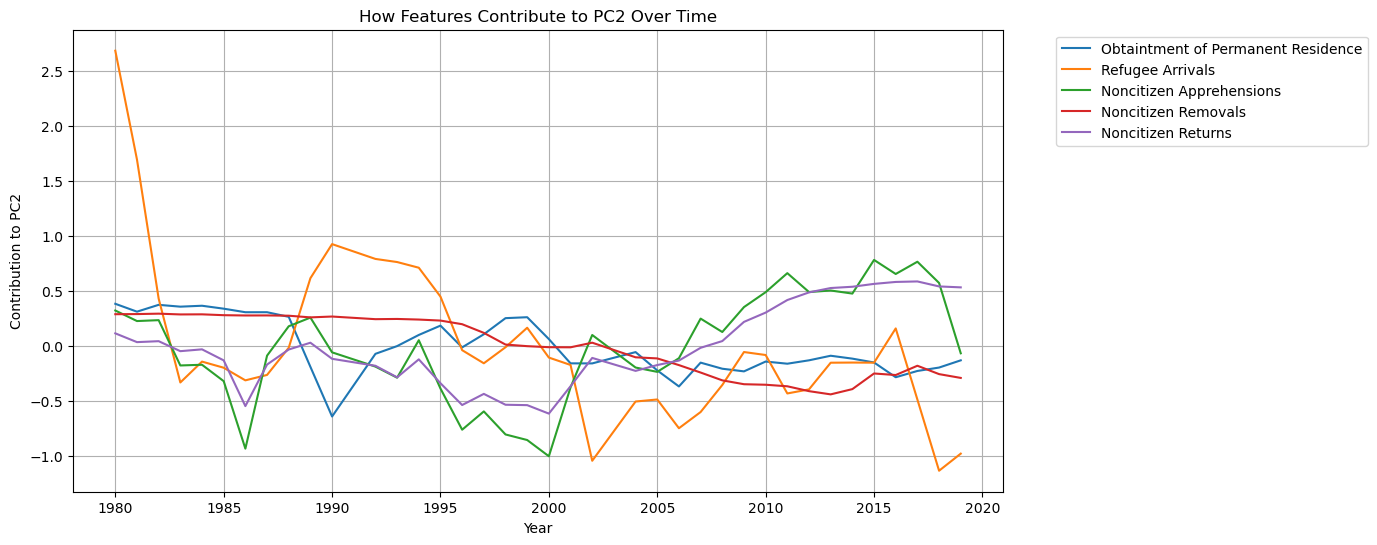

In [74]:
#plot pc2 contributions
fig, ax = plt.subplots(figsize=(12, 6))

for feature in contributions2.drop(columns=['Year']).columns:
    ax.plot(contributions2['Year'], contributions2[feature], label=feature)

ax.set_title("How Features Contribute to PC2 Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Contribution to PC2")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.show()

PC2 normally captures the patterns of features that dont fit in with those in PC1- In this plot, we see that refugee arrivals is behaving quite differently to all the other features. While there are slight variances between obtainment of permanent residency, noncitizen apprehensions, noncitizen removals, and noncitizen returns they all follow similar trends. This could indicate that refugee arrivals are driven by outside factors such as global conflicts. Overall, this explains why refugee arrivals moved in opposing directions to that of the other features.